In [34]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300, 'savefig.dpi': 300})
warnings.filterwarnings('ignore')

def find_project_root(current_path, marker="requirements.txt"):
    current = Path(current_path).resolve()
    for _ in range(5):
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError(f"Не удалось найти корень проекта (файл {marker})")

PROJECT_ROOT = find_project_root(os.getcwd())
sys.path.append(str(PROJECT_ROOT))

# Данные

In [35]:
df = pd.read_parquet(rf"{PROJECT_ROOT}\data\processed\dtp_msk.parquet")

# Удаляем УТЕЧКИ ДАННЫХ (ex-post факторы)
leakage_cols = [
    'category', 'scheme', 'ppl_count', 'ppl_pass_count', 'ppl_ped_count', 
    'ppl_solo_count', 'ppl_ped_worker_count', 'ppl_ped_other_count',
    'vh_count', 'vh_count_car', 'vh_count_truck', 'vh_count_bus', 
    'vh_count_moto', 'vh_count_special', 'vh_count_brand_ru', 
    'vh_count_brand_premium', 'vh_count_brand_chinese', 'vh_count_brand_mass', 
    'vh_count_brand_commercial', 'vh_count_color_dark', 'vh_count_color_light', 
    'vh_count_color_colored', 'vh_is_mass', 'nearby_objects_count'
]
df_clean = df.drop(columns=leakage_cols, errors='ignore')
df_clean['target'] = (df_clean['target'] > 0).astype(int)

X = df_clean.drop(columns=['target'])
y = df_clean['target']

# Матрицы
cat_features = [c for c in ['light_cat', 'region_id'] if c in X.columns]
X_cat = X.copy()

cols_to_drop = ['region_id', 'lat', 'long']
X_logit_raw = X.drop(columns=[c for c in cols_to_drop if c in X.columns])
X_logit = pd.get_dummies(X_logit_raw, columns=['light_cat'], drop_first=True) if 'light_cat' in X_logit_raw.columns else X_logit_raw.copy()

# Сплит
X_cat_train, X_cat_test, y_train, y_test = train_test_split(X_cat, y, test_size=0.2, random_state=42, stratify=y)
X_logit_train, X_logit_test, _, _ = train_test_split(X_logit, y, test_size=0.2, random_state=42, stratify=y)


# Baseline ML и SHAP

In [36]:
print("=== 1. ОБУЧЕНИЕ CATBOOST ===")
cb_model = CatBoostClassifier(iterations=500, random_seed=42, auto_class_weights='Balanced', verbose=0)
cb_model.fit(X_cat_train, y_train, cat_features=cat_features)
cb_probs = cb_model.predict_proba(X_cat_test)[:, 1]
cb_roc = roc_auc_score(y_test, cb_probs)
print(f"CatBoost ROC-AUC: {cb_roc:.4f}")

=== 1. ОБУЧЕНИЕ CATBOOST ===
CatBoost ROC-AUC: 0.7550


In [37]:
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_cat_train)
shap_sum = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({'feature': X_cat_train.columns, 'importance': shap_sum}).sort_values('importance', ascending=False)
all_shap_features = importance_df['feature'].tolist()

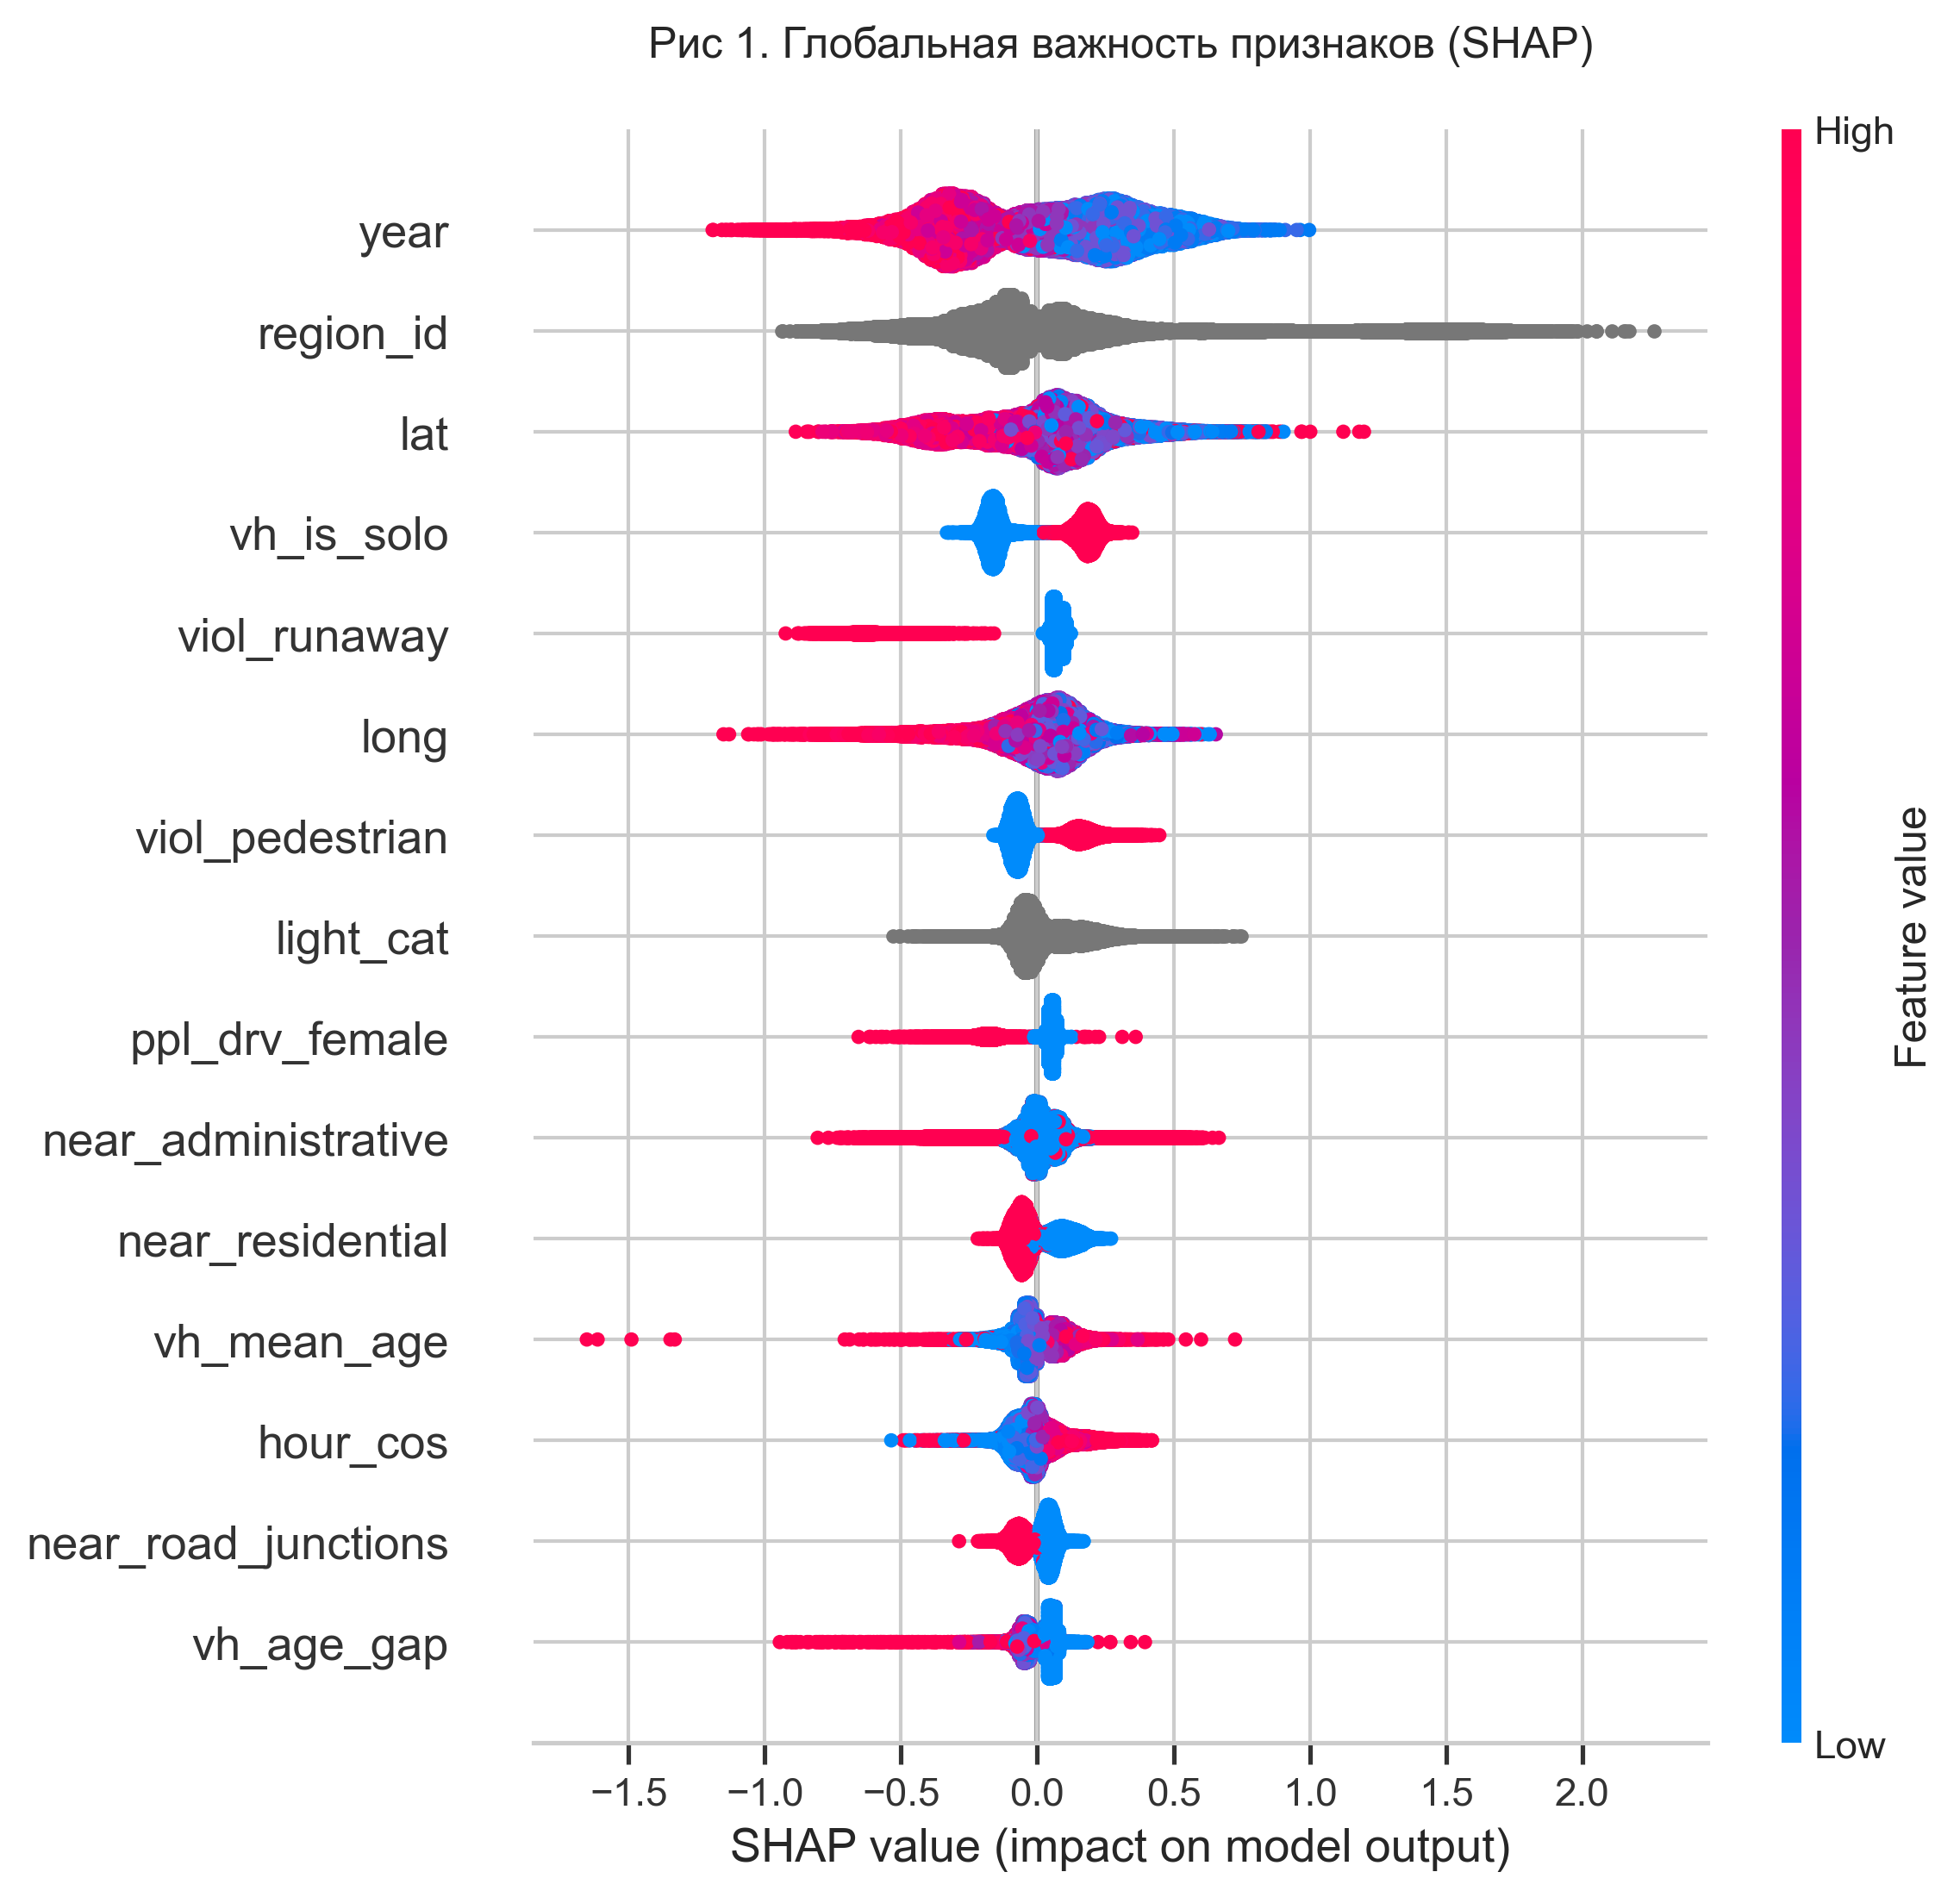

In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_cat_train, max_display=15, show=False)
plt.title("Рис 1. Глобальная важность признаков (SHAP)", pad=20)
plt.tight_layout()
plt.show()

# Провал классики (Базовый Логит и Lasso)

In [39]:
print("=== 2. БАЗОВЫЙ ЛОГИТ И LASSO ===")
scaler_base = StandardScaler()
X_logit_train_scaled = scaler_base.fit_transform(X_logit_train)
X_logit_test_scaled = scaler_base.transform(X_logit_test)

# Базовый логит (Без регуляризации)
try:
    logit_base = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced', penalty=None)
    logit_base.fit(X_logit_train_scaled, y_train)
except:
    logit_base = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced', penalty='none')
    logit_base.fit(X_logit_train_scaled, y_train)
    
lb_probs = logit_base.predict_proba(X_logit_test_scaled)[:, 1]
lb_roc = roc_auc_score(y_test, lb_probs)

# Считаем VIF для базового логита
X_vif_base = X_logit_train.astype(float)
X_vif_base = X_vif_base.loc[:, X_vif_base.std() > 0]
X_vif_base = add_constant(X_vif_base)
max_vif_base = max([variance_inflation_factor(X_vif_base.values, i) for i in range(1, X_vif_base.shape[1])])
print(f"Базовый Logit ROC-AUC: {lb_roc:.4f} | Max VIF: {max_vif_base:.2f}")

=== 2. БАЗОВЫЙ ЛОГИТ И LASSO ===
Базовый Logit ROC-AUC: 0.6693 | Max VIF: 476.97


In [40]:
# Lasso
logit_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=1000, random_state=42, class_weight='balanced')
logit_lasso.fit(X_logit_train_scaled, y_train)
lasso_probs = logit_lasso.predict_proba(X_logit_test_scaled)[:, 1]
lasso_roc = roc_auc_score(y_test, lasso_probs)
non_zero = sum(logit_lasso.coef_[0] != 0)
print(f"Lasso ROC-AUC: {lasso_roc:.4f} | Осталось признаков: {non_zero} из {X_logit_train_scaled.shape[1]}")


Lasso ROC-AUC: 0.6694 | Осталось признаков: 59 из 63


# Метод Локтя

In [41]:
print("=== 3. МЕТОД ЛОКТЯ (Поиск оптимума) ===")
results = []
for k in [5, 10, 15, 20, 25, 30]:
    top_cols = [c for c in X_logit_train.columns if any(c == f or c.startswith(f + '_') for f in all_shap_features[:k])]
    X_train_k = X_logit_train[top_cols]
    
    # VIF
    X_vif_clean = add_constant(X_train_k.astype(float).loc[:, X_train_k.std() > 0])
    max_vif = max([variance_inflation_factor(X_vif_clean.values, i) for i in range(1, X_vif_clean.shape[1])])
    
    # ROC
    scaler_k = StandardScaler()
    X_train_k_scaled = scaler_k.fit_transform(X_train_k)
    X_test_k_scaled = scaler_k.transform(X_logit_test[top_cols])
    
    try:
        logit_k = LogisticRegression(penalty=None, max_iter=1000, random_state=42, class_weight='balanced')
        logit_k.fit(X_train_k_scaled, y_train)
    except:
        logit_k = LogisticRegression(penalty='none', max_iter=1000, random_state=42, class_weight='balanced')
        logit_k.fit(X_train_k_scaled, y_train)
        
    roc_k = roc_auc_score(y_test, logit_k.predict_proba(X_test_k_scaled)[:, 1])
    results.append({'Top_K': k, 'Features_Used': len(top_cols), 'Max_VIF': max_vif, 'ROC_AUC': roc_k})

results_df = pd.DataFrame(results)

=== 3. МЕТОД ЛОКТЯ (Поиск оптимума) ===


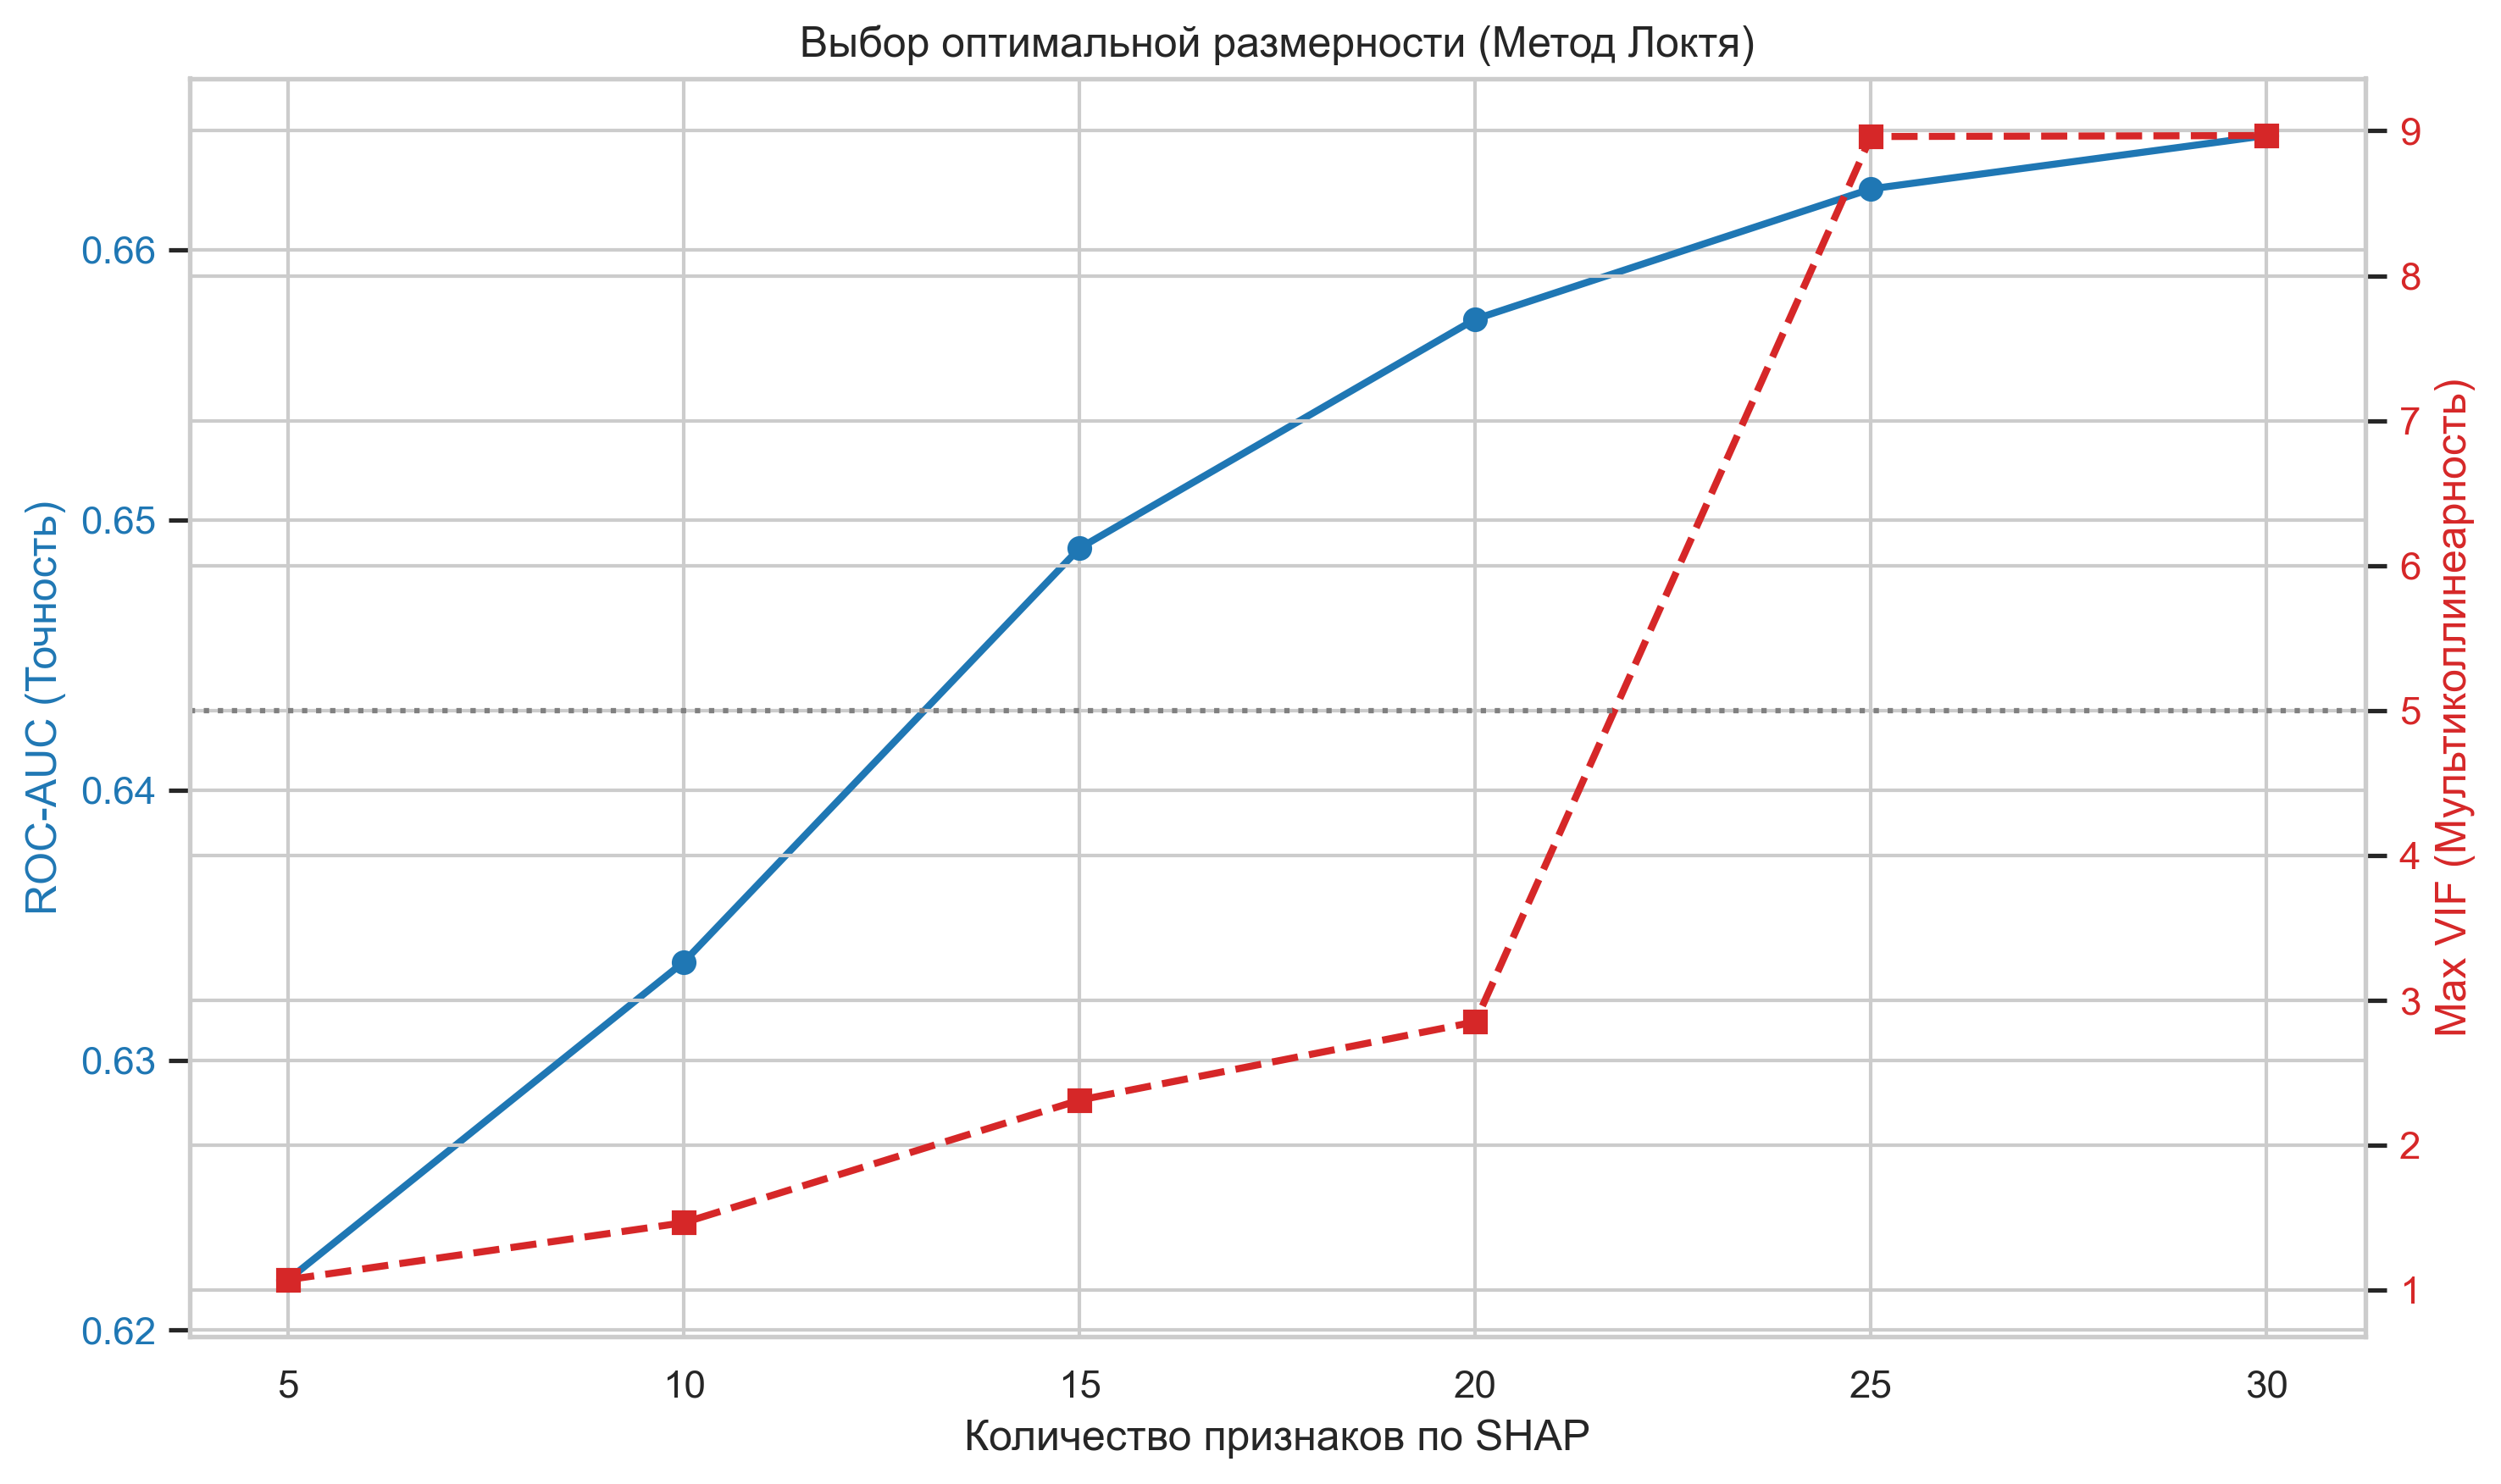

In [42]:
# График 2: Метод локтя
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Количество признаков по SHAP')
ax1.set_ylabel('ROC-AUC (Точность)', color='tab:blue')
ax1.plot(results_df['Top_K'], results_df['ROC_AUC'], marker='o', color='tab:blue', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()  
ax2.set_ylabel('Max VIF (Мультиколлинеарность)', color='tab:red')  
ax2.plot(results_df['Top_K'], results_df['Max_VIF'], marker='s', color='tab:red', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.axhline(y=5, color='gray', linestyle=':', label='Критический порог VIF = 5')

plt.title("Выбор оптимальной размерности (Метод Локтя)")
fig.tight_layout()  
plt.show()

# Финальная Эконометрика (ТОП-20)

In [46]:
print("=== 4. ФИНАЛЬНАЯ МОДЕЛЬ (ТОП-20) ===")
top_20_cols = [c for c in X_logit_train.columns if any(c == f or c.startswith(f + '_') for f in all_shap_features[:20])]
X_train_sm = add_constant(X_logit_train[top_20_cols].astype(float))

sm_model = sm.Logit(y_train, X_train_sm).fit(disp=False)
params = sm_model.params.drop('const')
pvalues = sm_model.pvalues.drop('const')
conf = sm_model.conf_int().drop('const')

or_df_20 = pd.DataFrame({
    'Feature': params.index,
    'Odds_Ratio': np.exp(params),
    'CI_Lower': np.exp(conf[0]),
    'CI_Upper': np.exp(conf[1]),
    'P_value': pvalues
}).sort_values('Odds_Ratio', ascending=True)

print(or_df_20)

=== 4. ФИНАЛЬНАЯ МОДЕЛЬ (ТОП-20) ===
                                   Feature  Odds_Ratio  CI_Lower  CI_Upper  \
viol_runaway                  viol_runaway    0.462015  0.432966  0.493014   
near_residential          near_residential    0.703835  0.679453  0.729091   
ppl_drv_female              ppl_drv_female    0.801447  0.771881  0.832145   
weather_overcast          weather_overcast    0.816274  0.786291  0.847402   
near_road_junctions    near_road_junctions    0.850342  0.820561  0.881205   
near_administrative    near_administrative    0.874387  0.838125  0.912218   
year                                  year    0.911135  0.905911  0.916390   
month_sin                        month_sin    0.936494  0.914243  0.959287   
light_cat_twilight      light_cat_twilight    0.954335  0.826762  1.101593   
month_cos                        month_cos    0.963385  0.936501  0.991042   
vh_age_gap                      vh_age_gap    1.002091  0.997909  1.006290   
vh_mean_age                

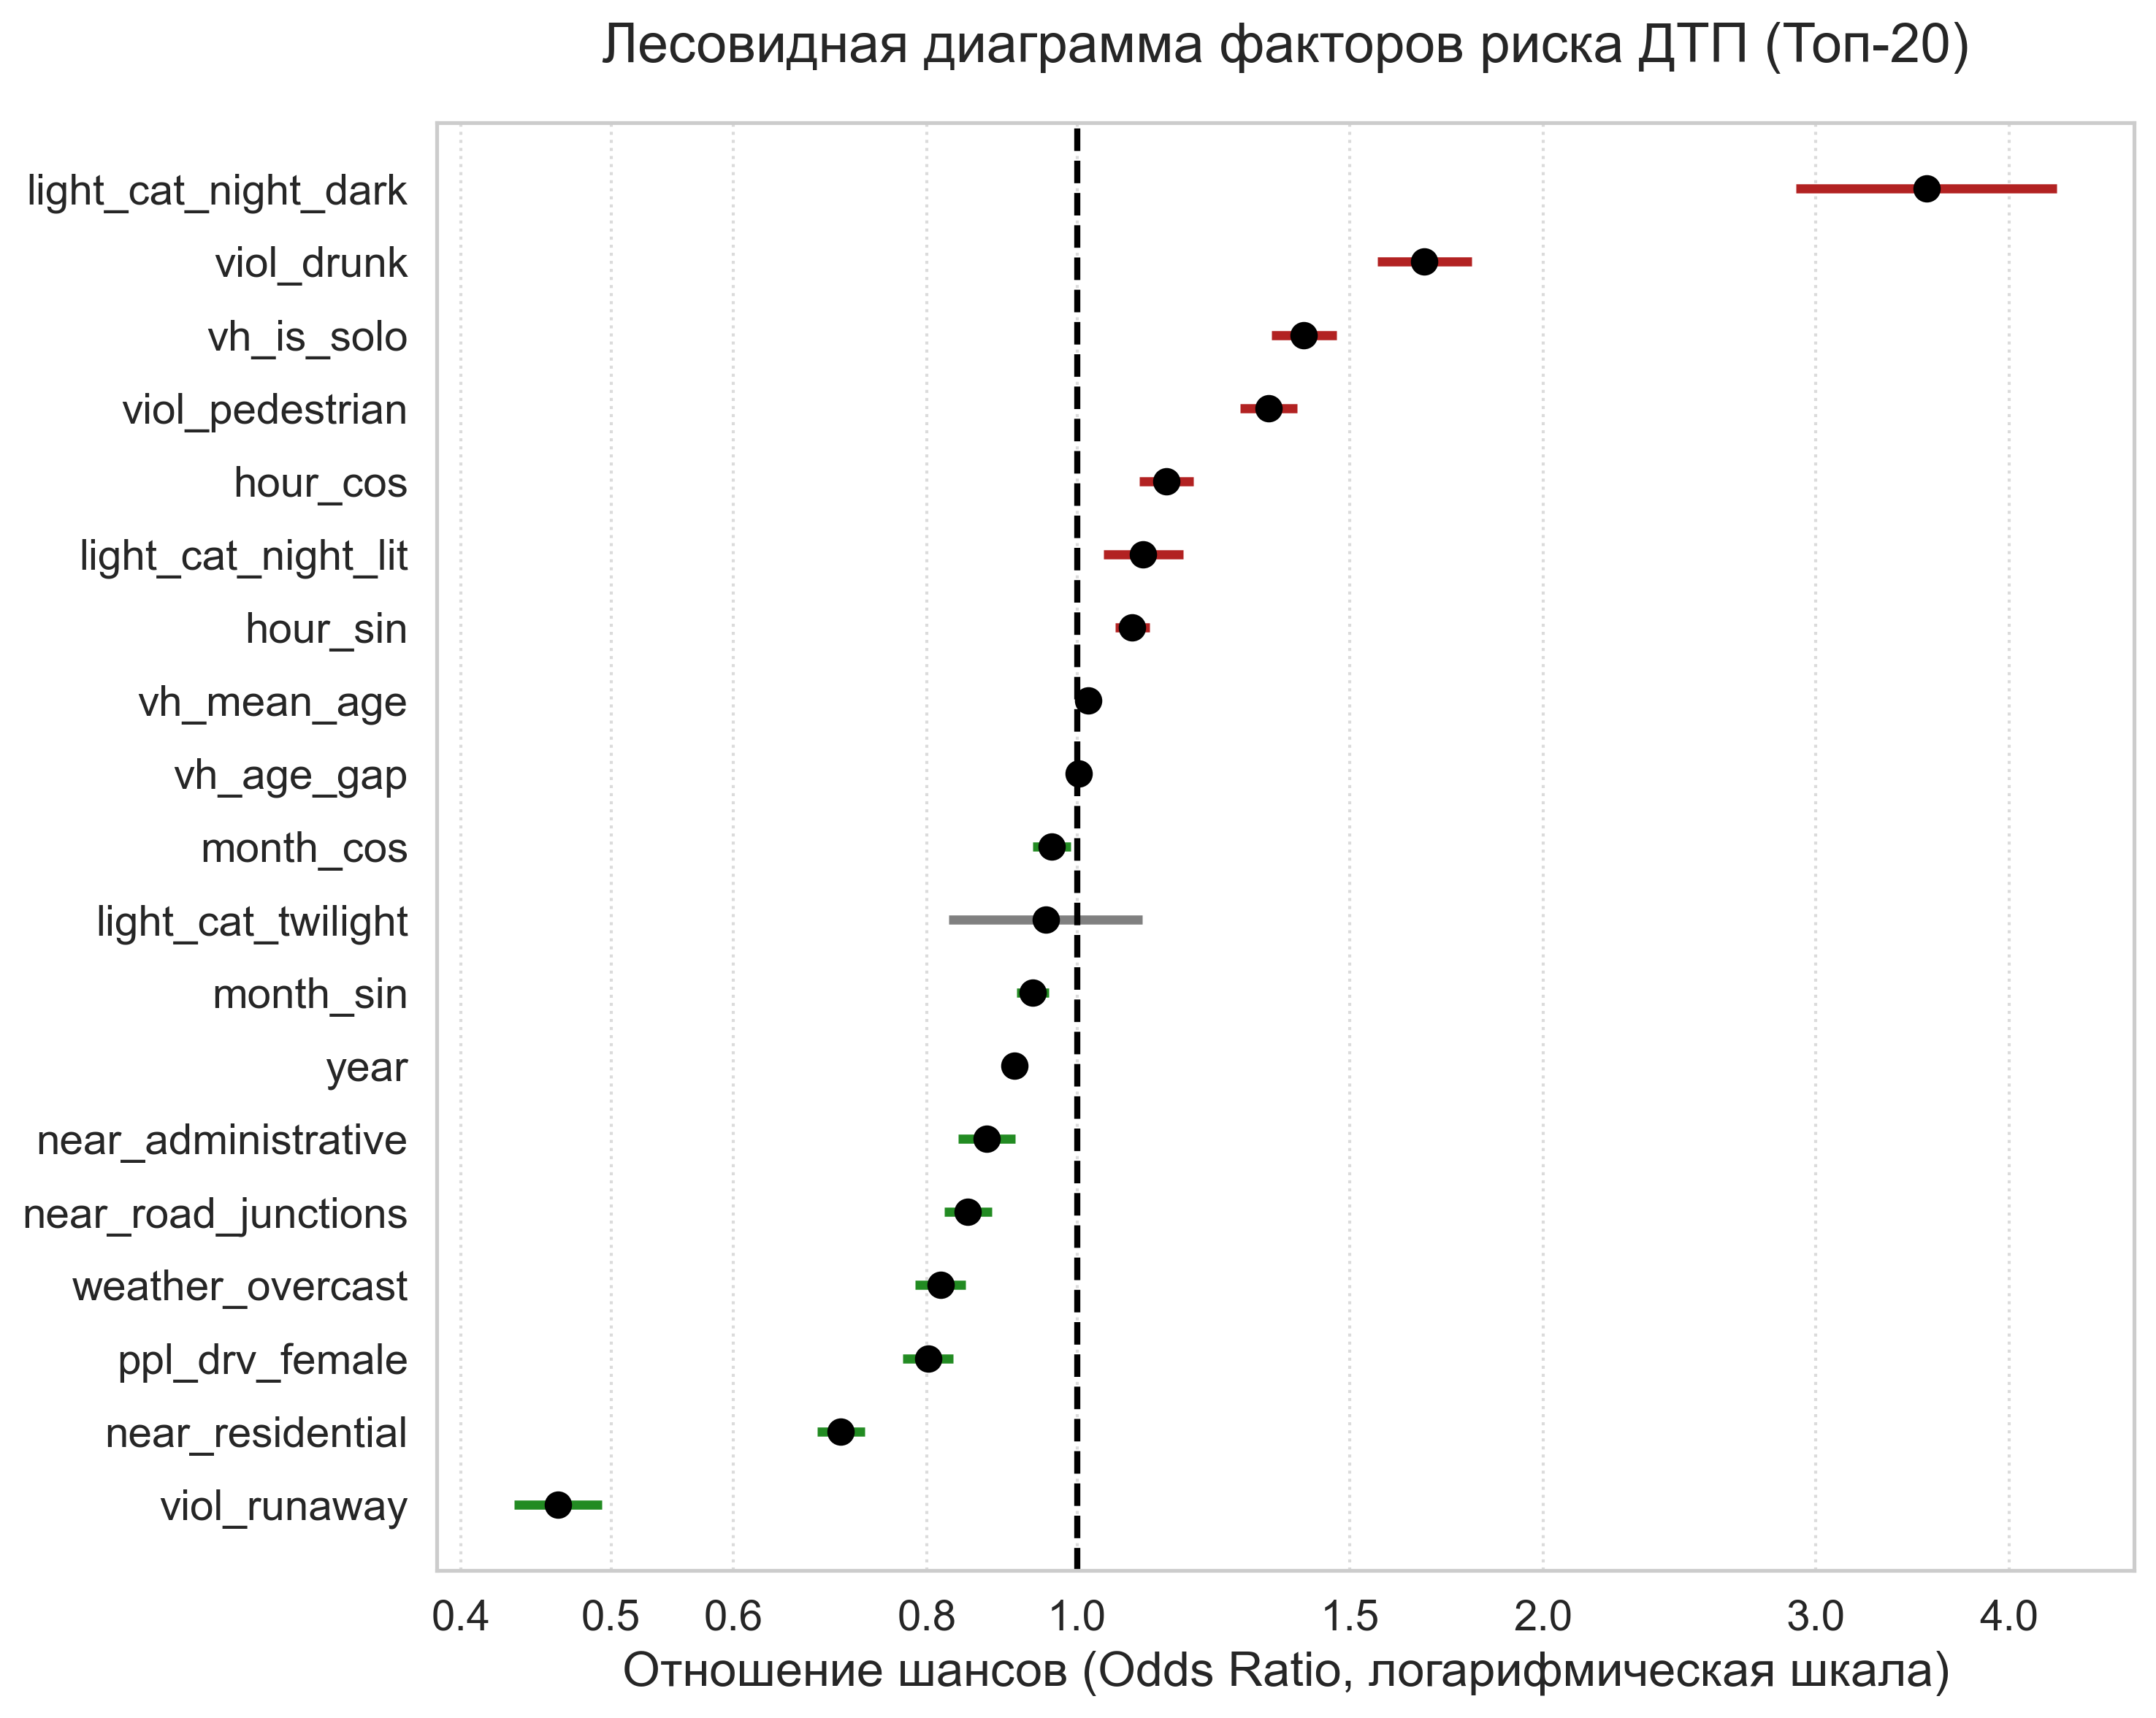

In [49]:
plt.figure(figsize=(10, 8))

lower_error = or_df_20["Odds_Ratio"] - or_df_20["CI_Lower"]
upper_error = or_df_20["CI_Upper"] - or_df_20["Odds_Ratio"]
xerr = [lower_error, upper_error]

colors = []
for idx, row in or_df_20.iterrows():
    if row["P_value"] > 0.05:
        colors.append("gray")
    elif row["Odds_Ratio"] < 1:
        colors.append("forestgreen")
    else:
        colors.append("firebrick")

plt.errorbar(
    x=or_df_20["Odds_Ratio"],
    y=or_df_20["Feature"],
    xerr=xerr,
    fmt="o",
    color="black",
    ecolor=colors,
    elinewidth=3,
    capsize=0,
    markersize=8,
)

plt.axvline(x=1, color="black", linestyle="--", linewidth=2)
plt.xscale("log")
ticks = [0.4, 0.5, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0]

plt.xticks(ticks, ticks, fontsize=14)                     # Подписи оси X
plt.yticks(fontsize=14)                                   # Названия фич на оси Y
plt.xlabel("Отношение шансов (Odds Ratio, логарифмическая шкала)", fontsize=16)
plt.title("Лесовидная диаграмма факторов риска ДТП (Топ-20)", fontsize=18, pad=20)

plt.grid(axis="x", linestyle=":", alpha=0.7)
plt.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("fig3_forest_plot_scientific.png", dpi=300)
plt.show()

# Сравнение ROC-кривых

=== 5. ПОСТРОЕНИЕ ROC-КРИВЫХ ===


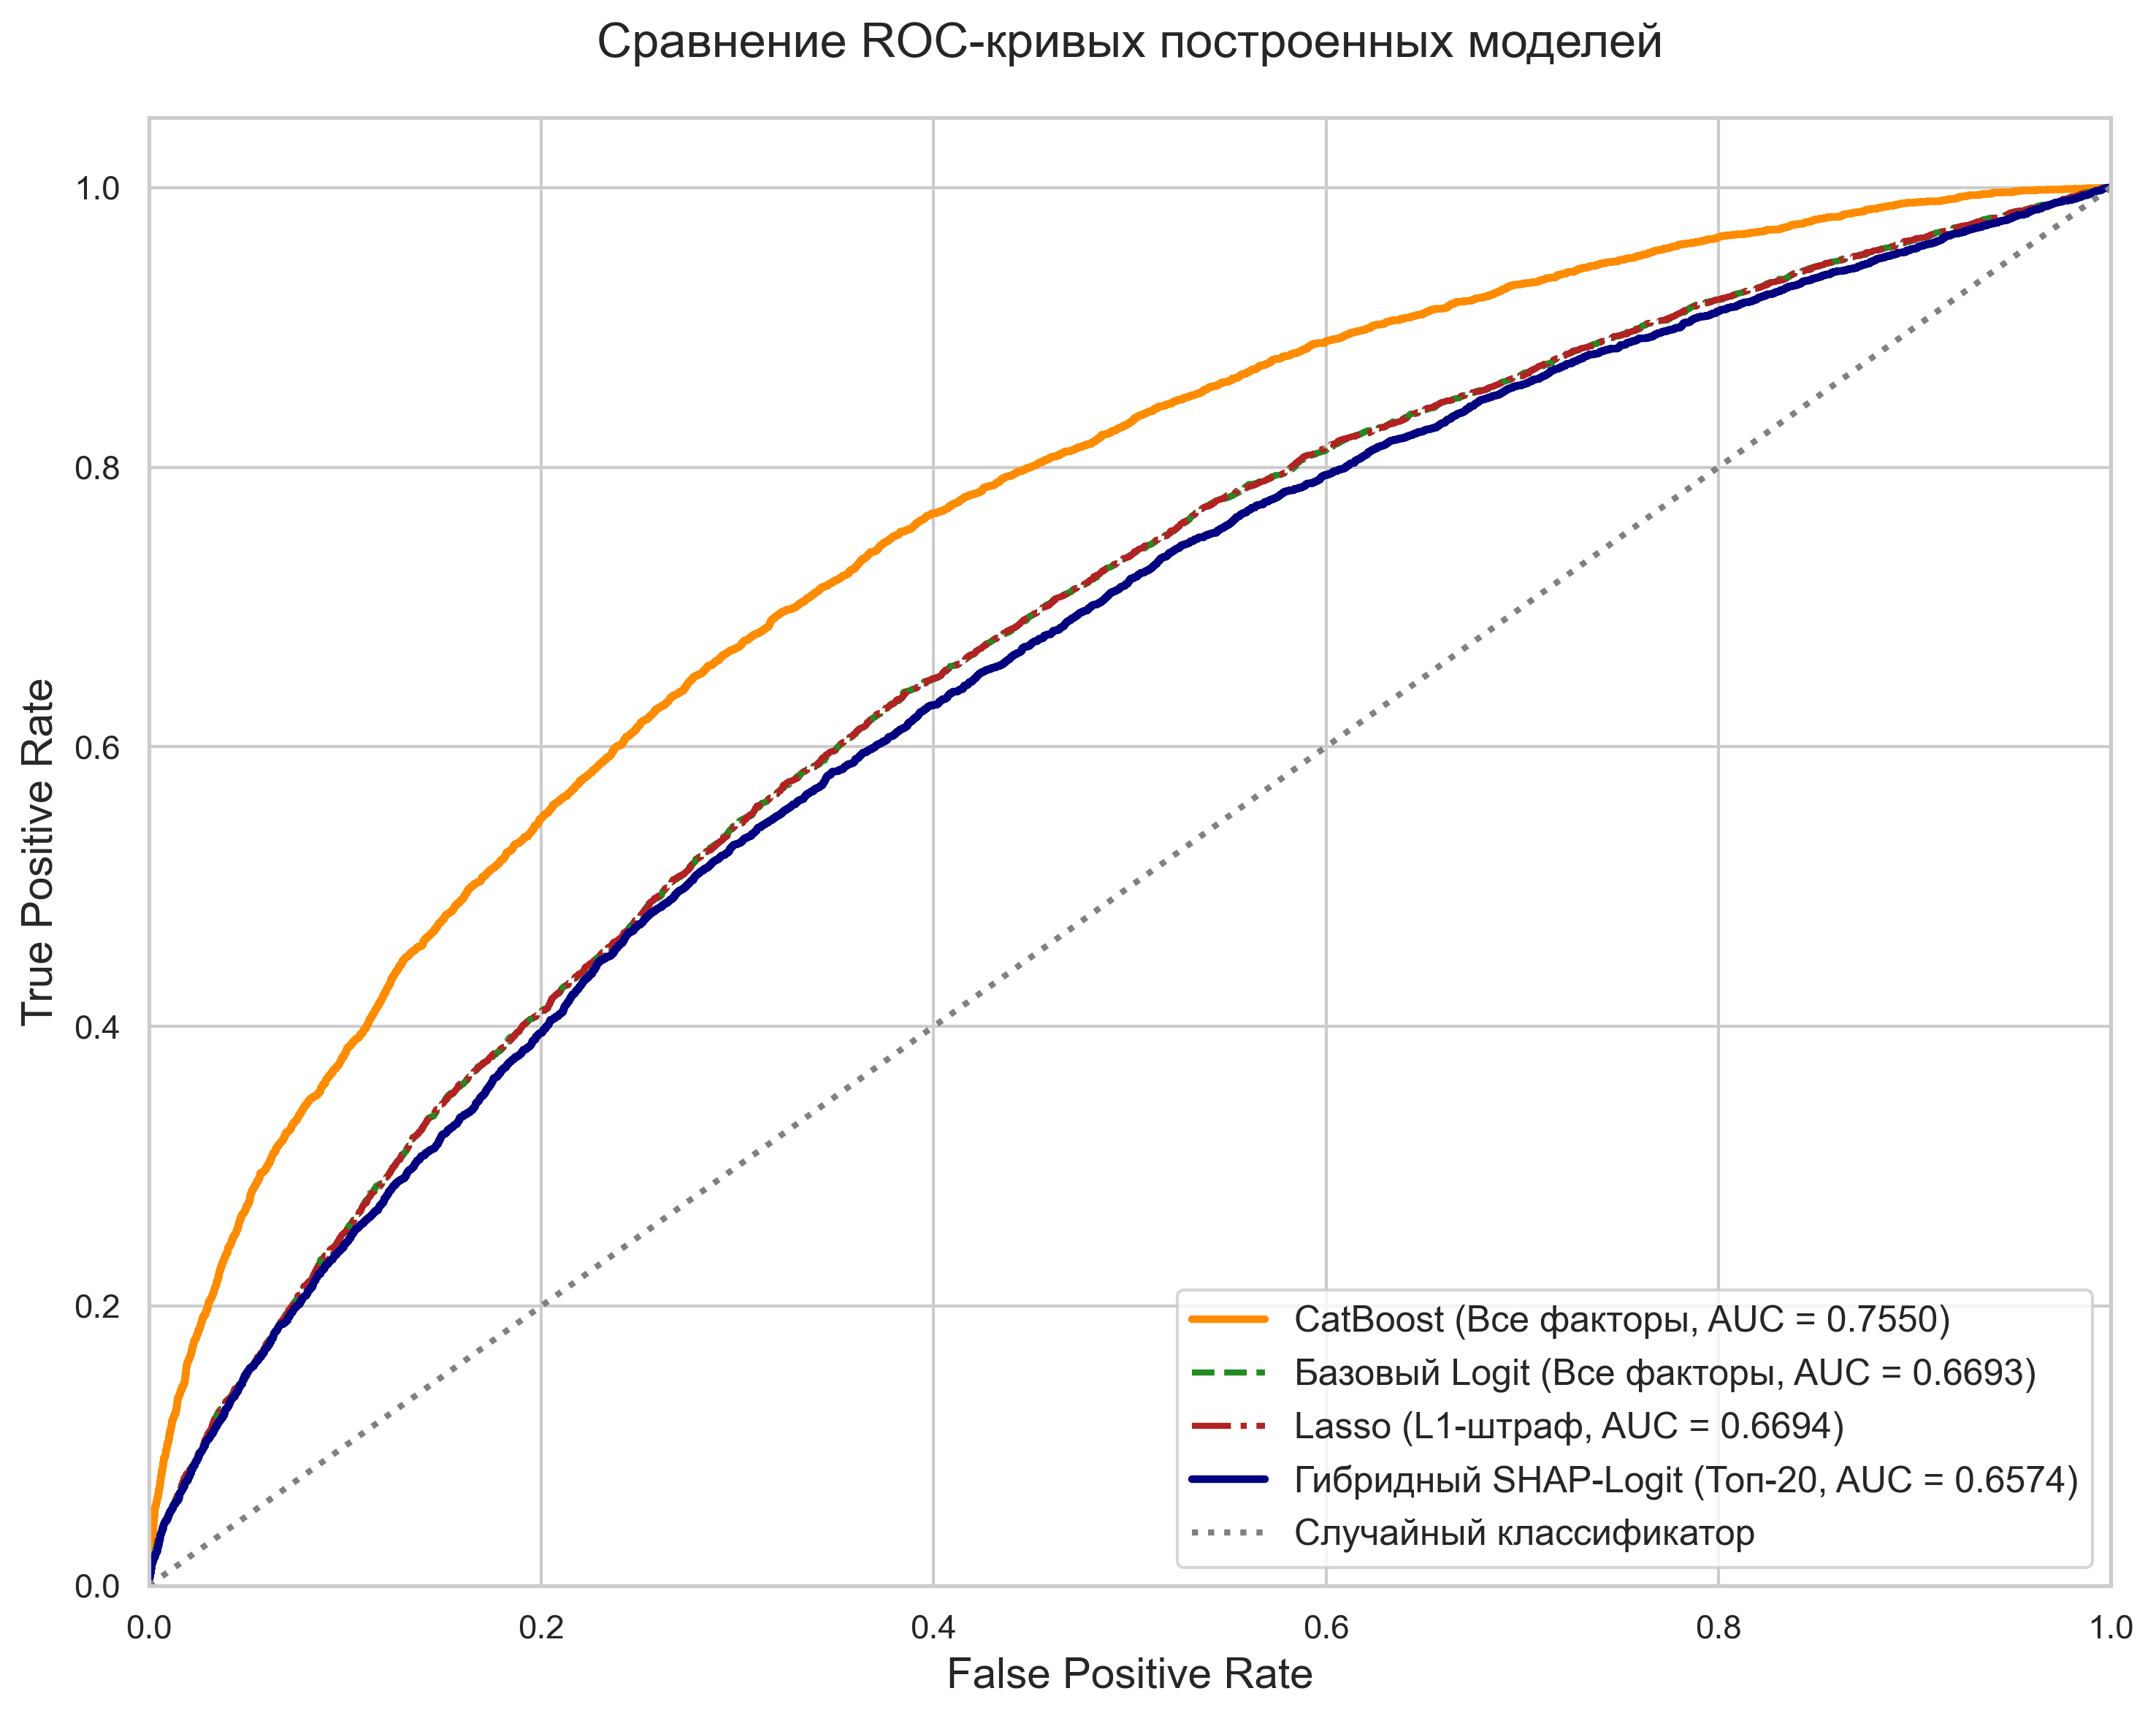

In [45]:
print("=== 5. ПОСТРОЕНИЕ ROC-КРИВЫХ ===")
# Получаем вероятности для Топ-20 через sklearn (чтобы честно сравнить на тестовой)
scaler_20 = StandardScaler()
X_train_20_sc = scaler_20.fit_transform(X_logit_train[top_20_cols])
X_test_20_sc = scaler_20.transform(X_logit_test[top_20_cols])

try:
    logit_20 = LogisticRegression(penalty=None, max_iter=1000, random_state=42, class_weight='balanced').fit(X_train_20_sc, y_train)
except:
    logit_20 = LogisticRegression(penalty='none', max_iter=1000, random_state=42, class_weight='balanced').fit(X_train_20_sc, y_train)

ls_probs = logit_20.predict_proba(X_test_20_sc)[:, 1]
ls_roc = roc_auc_score(y_test, ls_probs)

fpr_cb, tpr_cb, _ = roc_curve(y_test, cb_probs)
fpr_lb, tpr_lb, _ = roc_curve(y_test, lb_probs)
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, lasso_probs)
fpr_ls, tpr_ls, _ = roc_curve(y_test, ls_probs)

plt.figure(figsize=(10, 8))
plt.plot(fpr_cb, tpr_cb, color='darkorange', linewidth=2.5, label=f'CatBoost (Все факторы, AUC = {cb_roc:.4f})')
plt.plot(fpr_lb, tpr_lb, color='forestgreen', linewidth=2, linestyle='--', label=f'Базовый Logit (Все факторы, AUC = {lb_roc:.4f})')
plt.plot(fpr_lasso, tpr_lasso, color='firebrick', linewidth=2, linestyle='-.', label=f'Lasso (L1-штраф, AUC = {lasso_roc:.4f})')
plt.plot(fpr_ls, tpr_ls, color='navy', linewidth=2.5, label=f'Гибридный SHAP-Logit (Топ-20, AUC = {ls_roc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=2, label='Случайный классификатор')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Сравнение ROC-кривых построенных моделей', fontsize=16, pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()